Chargement des données pour le traitement

In [1]:
import pandas as pd
try:
    df = pd.read_csv(
        'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
    )
except Exception as e:
    print(f"Une erreur s'est produite lors de la lecture du fichier CSV: {e}")

/tmp/ipykernel_45584/912013414.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [2]:
df.sample(20)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
76810,19,Corrèze,22,Benayes,Emmanuel,MACRON,60
199439,61,Orne,124,La Coulonche,Éric,ZEMMOUR,9
39316,12,Aveyron,69,Combret,Fabien,ROUSSEL,8
502416,25,Doubs,275,Glère,NaN,nuls,4
259675,34,Hérault,124,Lacoste,Anne,HIDALGO,4
52526,47,Lot-et-Garonne,236,Sainte-Colombe-de-Duras,Fabien,ROUSSEL,1
93242,60,Oise,323,Janville,Emmanuel,MACRON,73
334713,48,Lozère,178,Saint-Privat-de-Vallongue,Valérie,PÉCRESSE,6
230251,52,Haute-Marne,30,Autigny-le-Petit,Jean-Luc,MÉLENCHON,5
286140,12,Aveyron,187,Prades-d'Aubrac,Yannick,JADOT,5


In [3]:
#Question 1
# Code commune
df["code_commune"] = (
    df["code_departement"].astype(str) +
    df["code_commune"].astype(str).str.zfill(3)
)

# Candidat
df["candidat"] = df["prenom"] + " " + df["nom"]

df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38,Nathalie ARTHAUD
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8,Nathalie ARTHAUD
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0,Nathalie ARTHAUD


In [ ]:
#Question 2
df_candidats = df[~df["nom"].isin(['blancs', 'nuls', 'abstentions'])]

candidats = df_candidats["candidat"].nunique()

f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."

"En 2022, il y avait 12 candidats à l'élection présidentielle."

In [ ]:

df_exprimes = df[~df["nom"].isin(['blancs', 'nuls', 'abstentions'])]

resultats = (
    df_exprimes
    .groupby("candidat", as_index=False)["voix"]
    .sum()
)

total_exprimes = resultats["voix"].sum()

resultats["pourcentage"] = (
    resultats["voix"] / total_exprimes * 100
).round(2)

resultats = resultats.sort_values(by="voix", ascending=False)

resultats.head(12)

['ARTHAUD' 'ROUSSEL' 'MACRON' 'LASSALLE' 'LE PEN' 'ZEMMOUR' 'MÉLENCHON'
 'HIDALGO' 'JADOT' 'PÉCRESSE' 'POUTOU' 'DUPONT-AIGNAN' 'abstentions'
 'blancs' 'nuls']


,candidat,voix,pourcentage
1,Emmanuel MACRON,9783058,27.85
5,Marine LE PEN,8133828,23.15
4,Jean-Luc MÉLENCHON,7712520,21.95
11,Éric ZEMMOUR,2485226,7.07
9,Valérie PÉCRESSE,1679001,4.78
10,Yannick JADOT,1627853,4.63
3,Jean LASSALLE,1101387,3.13
2,Fabien ROUSSEL,802422,2.28
7,Nicolas DUPONT-AIGNAN,725176,2.06
0,Anne HIDALGO,616478,1.75


In [79]:
df["candidat"] = df["prenom"] + " " + df["nom"]
df.sample(10)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
501043,21,Côte-d'Or,694,Villeferry,NaN,nuls,1,NaN
210964,95,Val-d'Oise,370,Marines,Éric,ZEMMOUR,147,Éric ZEMMOUR
511101,49,Maine-et-Loire,334,Sermaise,NaN,nuls,1,NaN
389526,05,Hautes-Alpes,145,Saint-Jean-Saint-Nicolas,Nicolas,DUPONT-AIGNAN,15,Nicolas DUPONT-AIGNAN
279191,84,Vaucluse,58,Lacoste,Anne,HIDALGO,1,Anne HIDALGO
324964,22,Côtes-d'Armor,141,Mantallot,Valérie,PÉCRESSE,2,Valérie PÉCRESSE
284837,09,Ariège,65,Boussenac,Yannick,JADOT,6,Yannick JADOT
457778,971,Guadeloupe,119,Petit-Canal,NaN,abstentions,4192,NaN
47194,32,Gers,112,Crastes,Fabien,ROUSSEL,4,Fabien ROUSSEL
185280,25,Doubs,350,Lougres,Éric,ZEMMOUR,30,Éric ZEMMOUR


## 2. Comparaison des scores départements aux moyennes nationales.

Q4. Créons un dataframe nommé score_departements stockant, pour chaque département, le nombre de vote obtenu pour chaque candidat et le score (en %).

In [80]:
# Votes par candidat
score_departements = df.groupby(["code_departement", "candidat"]).agg(
    votes = ("voix", "sum")
).reset_index()

# Récupération des totaux sans tenir compte des votes adressé à personne
total_dep = df.loc[~df["candidat"].isna()].groupby(["code_departement"]).agg(
    total = ("voix", "sum")
).reset_index()

# Rajout du total
score_departements = score_departements.merge(right=total_dep, how="left", on="code_departement")
score_departements


# Calcul du score
score_departements["score"] = round(100 * score_departements["votes"] / score_departements["total"], 2)  # .astype(str)  + "%"
score_departements = score_departements.drop(columns="total")

In [83]:
# affichage comme souhaité
x = score_departements.copy()
x["score"] = x["score"].astype(str)  + "%"
x

,code_departement,candidat,votes,score
0,01,Anne HIDALGO,5644,1.69%
1,01,Emmanuel MACRON,92206,27.69%
2,01,Fabien ROUSSEL,5938,1.78%
3,01,Jean LASSALLE,10876,3.27%
4,01,Jean-Luc MÉLENCHON,57832,17.37%
...,...,...,...,...
1291,fr_etranger,Nicolas DUPONT-AIGNAN,7074,1.42%
1292,fr_etranger,Philippe POUTOU,3145,0.63%
1293,fr_etranger,Valérie PÉCRESSE,20956,4.2%
1294,fr_etranger,Yannick JADOT,40774,8.17%


cellule de vérification ci-dessous avec le département 11

In [84]:
x.loc[x["code_departement"] == "11"].sort_values("votes", ascending=False)

,code_departement,candidat,votes,score
125,11,Marine LE PEN,64027,30.14%
121,11,Emmanuel MACRON,43104,20.29%
124,11,Jean-Luc MÉLENCHON,42039,19.79%
131,11,Éric ZEMMOUR,18434,8.68%
123,11,Jean LASSALLE,12382,5.83%
129,11,Valérie PÉCRESSE,7350,3.46%
130,11,Yannick JADOT,6322,2.98%
120,11,Anne HIDALGO,6166,2.9%
122,11,Fabien ROUSSEL,5622,2.65%
127,11,Nicolas DUPONT-AIGNAN,4206,1.98%


Q5. Refaissons le lien avec le niveau national pour comparer le score départemental avec le score national. Et nommons ce dataframe score_departements, nous allons le réutiliser par la suite.

In [85]:
# Votes par candidat
nationale = df.groupby(["candidat"]).agg(
    votes_national = ("voix", "sum")
).reset_index()

# Récupération des totaux sans tenir compte des votes adressé à personne
total_nationale = sum(df.loc[~df["candidat"].isna()]["voix"])

# Calcul du score
nationale["score_national"] = round(100 * nationale["votes_national"] / total_nationale, 2) # .astype(str)  + "%"
nationale

# Jointure avec la table relatives aux départements
score_departements = score_departements.merge(right=nationale, on="candidat", how="left")
score_departements = score_departements.rename(columns={"votes": "votes_departement", "score": "score_departement"})
score_departements

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
0,01,Anne HIDALGO,5644,1.69,616478,1.75
1,01,Emmanuel MACRON,92206,27.69,9783058,27.85
2,01,Fabien ROUSSEL,5938,1.78,802422,2.28
3,01,Jean LASSALLE,10876,3.27,1101387,3.13
4,01,Jean-Luc MÉLENCHON,57832,17.37,7712520,21.95
...,...,...,...,...,...,...
1291,fr_etranger,Nicolas DUPONT-AIGNAN,7074,1.42,725176,2.06
1292,fr_etranger,Philippe POUTOU,3145,0.63,268904,0.77
1293,fr_etranger,Valérie PÉCRESSE,20956,4.20,1679001,4.78
1294,fr_etranger,Yannick JADOT,40774,8.17,1627853,4.63


In [86]:
# Affichage comme demandé
x = score_departements.copy()
x["score_departement"] = x["score_departement"].astype(str)  + "%"
x["score_national"] = x["score_national"].astype(str)  + "%"
x

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
0,01,Anne HIDALGO,5644,1.69%,616478,1.75%
1,01,Emmanuel MACRON,92206,27.69%,9783058,27.85%
2,01,Fabien ROUSSEL,5938,1.78%,802422,2.28%
3,01,Jean LASSALLE,10876,3.27%,1101387,3.13%
4,01,Jean-Luc MÉLENCHON,57832,17.37%,7712520,21.95%
...,...,...,...,...,...,...
1291,fr_etranger,Nicolas DUPONT-AIGNAN,7074,1.42%,725176,2.06%
1292,fr_etranger,Philippe POUTOU,3145,0.63%,268904,0.77%
1293,fr_etranger,Valérie PÉCRESSE,20956,4.2%,1679001,4.78%
1294,fr_etranger,Yannick JADOT,40774,8.17%,1627853,4.63%


cellule de vérification ci-dessous avec le département 1

In [87]:
x.loc[x["code_departement"] == "11"].sort_values("votes_departement", ascending=False)

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
125,11,Marine LE PEN,64027,30.14%,8133828,23.15%
121,11,Emmanuel MACRON,43104,20.29%,9783058,27.85%
124,11,Jean-Luc MÉLENCHON,42039,19.79%,7712520,21.95%
131,11,Éric ZEMMOUR,18434,8.68%,2485226,7.07%
123,11,Jean LASSALLE,12382,5.83%,1101387,3.13%
129,11,Valérie PÉCRESSE,7350,3.46%,1679001,4.78%
130,11,Yannick JADOT,6322,2.98%,1627853,4.63%
120,11,Anne HIDALGO,6166,2.9%,616478,1.75%
122,11,Fabien ROUSSEL,5622,2.65%,802422,2.28%
127,11,Nicolas DUPONT-AIGNAN,4206,1.98%,725176,2.06%


Q6. Créons une variable surrepresentation qui compare, en relatif, les scores nationaux et départementaux

In [88]:
score_departements["surrepresentation"] = round(((score_departements["score_departement"] / score_departements["score_national"]) - 1) * 100, 2)

In [89]:
# Affichage comme demandé (avec le symbole %)
x = score_departements.copy()
x["score_departement"] = x["score_departement"].astype(str)  + "%"
x["score_national"] = x["score_national"].astype(str)  + "%"
x["surrepresentation"] = x["surrepresentation"].astype(str)  + "%"
x

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
0,01,Anne HIDALGO,5644,1.69%,616478,1.75%,-3.43%
1,01,Emmanuel MACRON,92206,27.69%,9783058,27.85%,-0.57%
2,01,Fabien ROUSSEL,5938,1.78%,802422,2.28%,-21.93%
3,01,Jean LASSALLE,10876,3.27%,1101387,3.13%,4.47%
4,01,Jean-Luc MÉLENCHON,57832,17.37%,7712520,21.95%,-20.87%
...,...,...,...,...,...,...,...
1291,fr_etranger,Nicolas DUPONT-AIGNAN,7074,1.42%,725176,2.06%,-31.07%
1292,fr_etranger,Philippe POUTOU,3145,0.63%,268904,0.77%,-18.18%
1293,fr_etranger,Valérie PÉCRESSE,20956,4.2%,1679001,4.78%,-12.13%
1294,fr_etranger,Yannick JADOT,40774,8.17%,1627853,4.63%,76.46%


Q7. Créons une fonction pour représenter une figure similaire à Figure 1 pour un candidat donné des
principales surreprésentations (en valeur absolue) par département.

In [90]:
def display_surrepresentation(candidat: str, top: int=5):
    """
        Permet de représenter visuellement la surreprésentation des candidats

        Parameters
        ------------
            candidat : str
                Prenom et nom du candidat
            top : int
                le top a afficher (par défaut 5)

    """

    from matplotlib import pyplot as plt

    # Selection des données pour un candidat donné
    res = score_departements.loc[(
        (score_departements["candidat"] == candidat)
        )].sort_values(by="surrepresentation", key=abs, ascending=False).head(top) # On ordonne selon la valeur absolue de la surreprésentation

    res = res.sort_values("surrepresentation", ascending=True)

    plt.barh(y = res["code_departement"], width=res["surrepresentation"])
    plt.title("Top 5 des surreprésentation de " + candidat)
    plt.axvline(x=0)
    plt.show()

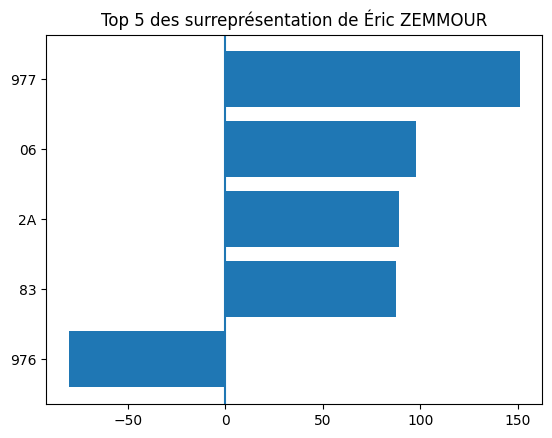

In [91]:
display_surrepresentation(candidat="Éric ZEMMOUR")

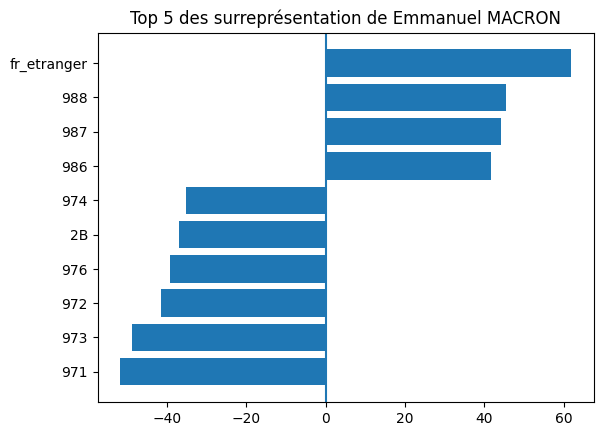

In [92]:
display_surrepresentation(candidat="Emmanuel MACRON", top=10)

## 3. Un peu de cartographie

### Question 8 : Faire une fonction permettant de restreindre score_departements en fonction d’un candidat. Commencer par tester sur Marine Le Pen (créer un nouvel objet, ne pas écraser score_departements nous allons l’utiliser à nouveau !). Faire une jointure au fond de carte des départements et effectuer une carte de la représentation

In [ ]:
from cartiflette import carti_download
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


class Cartographie:
    """
    Classe pour gérer la cartographie des départements français et la visualisation
    des scores par candidat.

    Attributs
    ---------
    departement_borders : GeoDataFrame | None
        Contient les frontières des départements téléchargées.
    """

    def __init__(self) -> None:
        """Initialise une instance de Cartographie sans frontières de départements."""
        self.departement_borders: gpd.GeoDataFrame | None = None

    def does_departement_borders_exist(self) -> bool:
        """
        Vérifie si les frontières des départements ont été téléchargées.

        Returns
        -------
        bool
            True si les frontières existent, False sinon.
        """
        return self.departement_borders is not None

    def download_departement_borders(
        self,
        values: list[str] = ["France"],
        crs: int = 4326,
        borders: str = "DEPARTEMENT",
        vectorfile_format: str = "geojson",
        simplification: int = 50,
        filter_by: str = "FRANCE_ENTIERE_DROM_RAPPROCHES",
        source: str = "EXPRESS-COG-CARTO-TERRITOIRE",
        year: int = 2022
    ) -> None:
        """
        Télécharge les frontières des départements français via Cartiflette.

        Paramètres
        ----------
        values : list[str], optional
            Liste de valeurs géographiques à télécharger (défaut ["France"]).
        crs : int, optional
            Système de coordonnées (défaut 4326).
        borders : str, optional
            Type de frontière à récupérer (défaut "DEPARTEMENT").
        vectorfile_format : str, optional
            Format du fichier vectoriel (défaut "geojson").
        simplification : int, optional
            Pourcentage de simplification géométrique (défaut 50).
        filter_by : str, optional
            Filtre sur la zone géographique (défaut "FRANCE_ENTIERE_DROM_RAPPROCHES").
        source : str, optional
            Source du téléchargement (défaut "EXPRESS-COG-CARTO-TERRITOIRE").
        year : int, optional
            Année des données (défaut 2022).

        Returns
        -------
        None
        """
        if not self.does_departement_borders_exist():
            try:
                self.departement_borders = carti_download(
                    values=values,
                    crs=crs,
                    borders=borders,
                    vectorfile_format=vectorfile_format,
                    simplification=simplification,
                    filter_by=filter_by,
                    source=source,
                    year=year,
                )
            except Exception as e:
                print(
                    "Une erreur s'est produite lors du téléchargement "
                    f"des frontières des départements: {e}"
                )
        else:
            print("Les frontières des départements ont déjà été téléchargées.")

    def afficher_resultats_filtre_score_candidat(
        self,
        df_score: pd.DataFrame,
        candidat: str = "Marine LE PEN",
        departement_code: str | None = None,
        afficher_carte: bool = False,
        figSize: tuple[int, int] = (12, 14)
    ):
        """
        Filtre les scores d'un candidat par département et trace la carte.

        Paramètres
        ----------
        df_score : pd.DataFrame
            DataFrame contenant les colonnes ['code_departement', 'candidat',
            'votes_departement', 'score_departement'].
        candidat : str, optional
            Nom du candidat à filtrer (défaut "Marine LE PEN").
        departement_code : str | None, optional
            Code département à filtrer, None pour tous les départements (défaut None).
        afficher_carte : bool, optional
            True pour afficher la carte après génération (défaut False).
        figSize : tuple[int, int], optional
            Taille de la figure matplotlib (défaut (12, 14)).
        """
        # Vérifier que toutes les colonnes nécessaires sont présentes
        required_cols = ['code_departement', 'candidat', 'votes_departement', 'score_departement']
        if not all(col in df_score.columns for col in required_cols):
            raise ValueError(f"Le DataFrame df_score doit contenir les colonnes {required_cols}")

        # Filtrer par candidat (insensible à la casse)
        df_candidat = df_score[df_score['candidat'].str.lower() == candidat.lower()]

        # Filtrer par département si fourni
        if departement_code is not None:
            df_candidat = df_candidat[df_candidat['code_departement'] == departement_code]

        # Merge avec les frontières
        df_plot = self.departement_borders.merge(
            df_candidat,
            right_on='code_departement',
            left_on='INSEE_DEP',
            how='left'
        )

        # Création figure
        fig, ax = plt.subplots(1, 1, figsize=figSize)

        # Colormap bleu ciel -> blanc -> rose foncé
        colors = ["#0CA8E6", "#FFFFFF", "#CD1039"]
        cmap = LinearSegmentedColormap.from_list("blue_pink", colors)

        # Tracé
        df_plot.plot(
            column='score_departement',
            cmap=cmap,
            linewidth=0.8,
            edgecolor='black',
            legend=True,
            ax=ax,
            legend_kwds={'label': "", 'orientation': "vertical", 'shrink': 0.5}
        )

        # Colorbar
        cbar = ax.get_figure().get_axes()[-1]
        cbar.text(
            x=0.5, y=1, s="% par rapport à la moyenne nationale",
            ha='center', va='bottom', transform=cbar.transAxes
        )

        # Flèche du Nord
        ax.annotate(
            'N',
            xy=(0.95, 0.98), xytext=(0.95, 0.92),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=14,
            xycoords=ax.transAxes
        )

        # Échelle
        scalebar = ScaleBar(
            1, units="m", dimension="si-length", location='lower right', pad=0.5,
            color='black', frameon=False
        )
        ax.add_artist(scalebar)

        # Supprimer axes
        ax.set_axis_off()

        # Titre
        ax.set_title(
            f"Score obtenu par le.a candidat.e {candidat} par département",
            fontsize=16
        )

        # Afficher la carte si demandé
        if afficher_carte:
            plt.show()


In [118]:
cartographie = Cartographie()
cartographie.download_departement_borders()

e:\ENSAI\2A\semestre2\python_4_data_science\eval_test\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


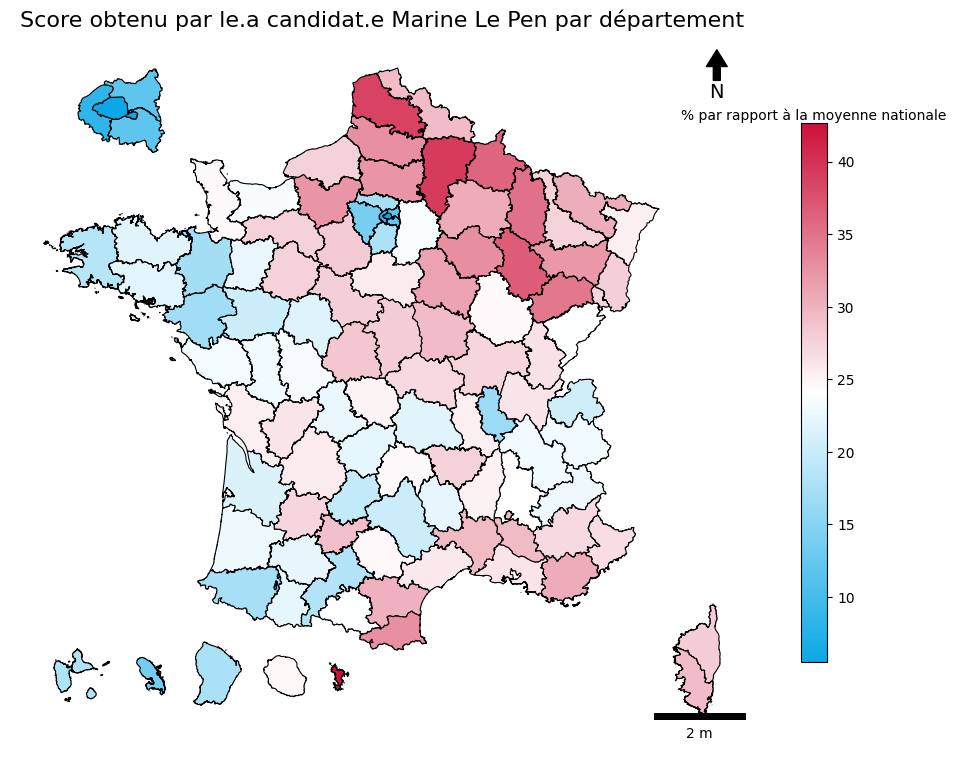

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
5,01,Marine LE PEN,86755,26.05,8133828,23.15,12.53
17,02,Marine LE PEN,104342,39.25,8133828,23.15,69.55
29,03,Marine LE PEN,50315,27.06,8133828,23.15,16.89
41,04,Marine LE PEN,26010,26.90,8133828,23.15,16.20
53,05,Marine LE PEN,19696,22.84,8133828,23.15,-1.34
...,...,...,...,...,...,...,...
1241,978,Marine LE PEN,853,14.90,8133828,23.15,-35.64
1253,986,Marine LE PEN,579,10.80,8133828,23.15,-53.35
1265,987,Marine LE PEN,11705,19.50,8133828,23.15,-15.77
1277,988,Marine LE PEN,13273,18.83,8133828,23.15,-18.66


In [ ]:
cartographie.afficher_resultats_filtre_score_candidat(df_score=score_departements, candidat="Marine Le Pen", afficher_carte=True)

e:\ENSAI\2A\semestre2\python_4_data_science\eval_test\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


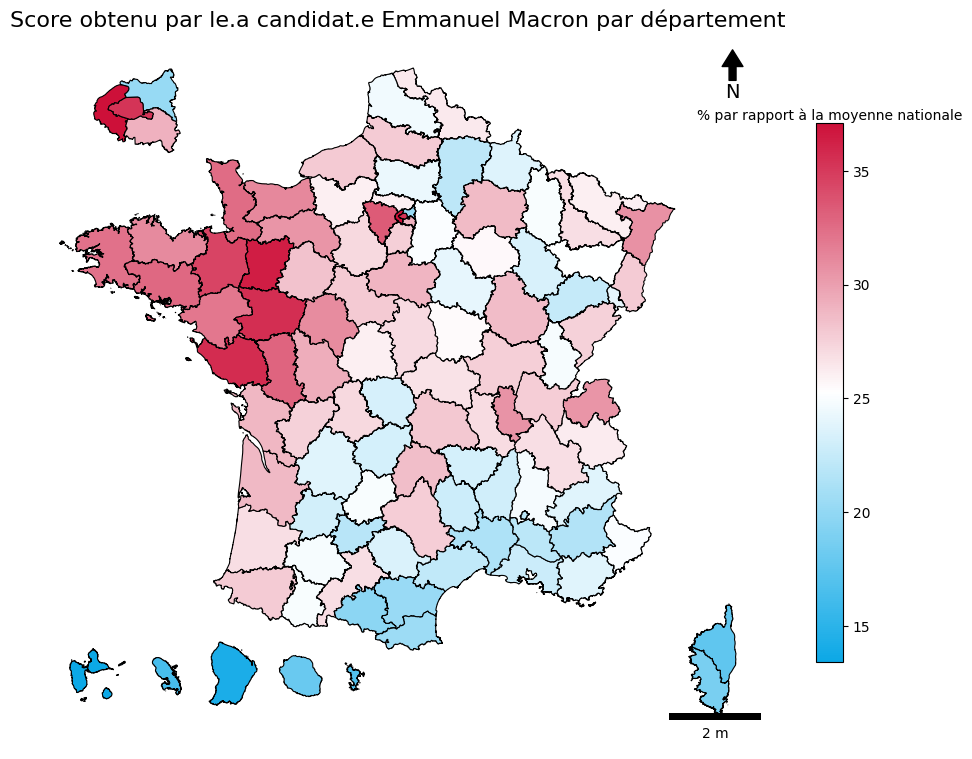

In [ ]:
cartographie.afficher_resultats_filtre_score_candidat(df_score=score_departements, candidat="Emmanuel Macron", afficher_carte=True)

e:\ENSAI\2A\semestre2\python_4_data_science\eval_test\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


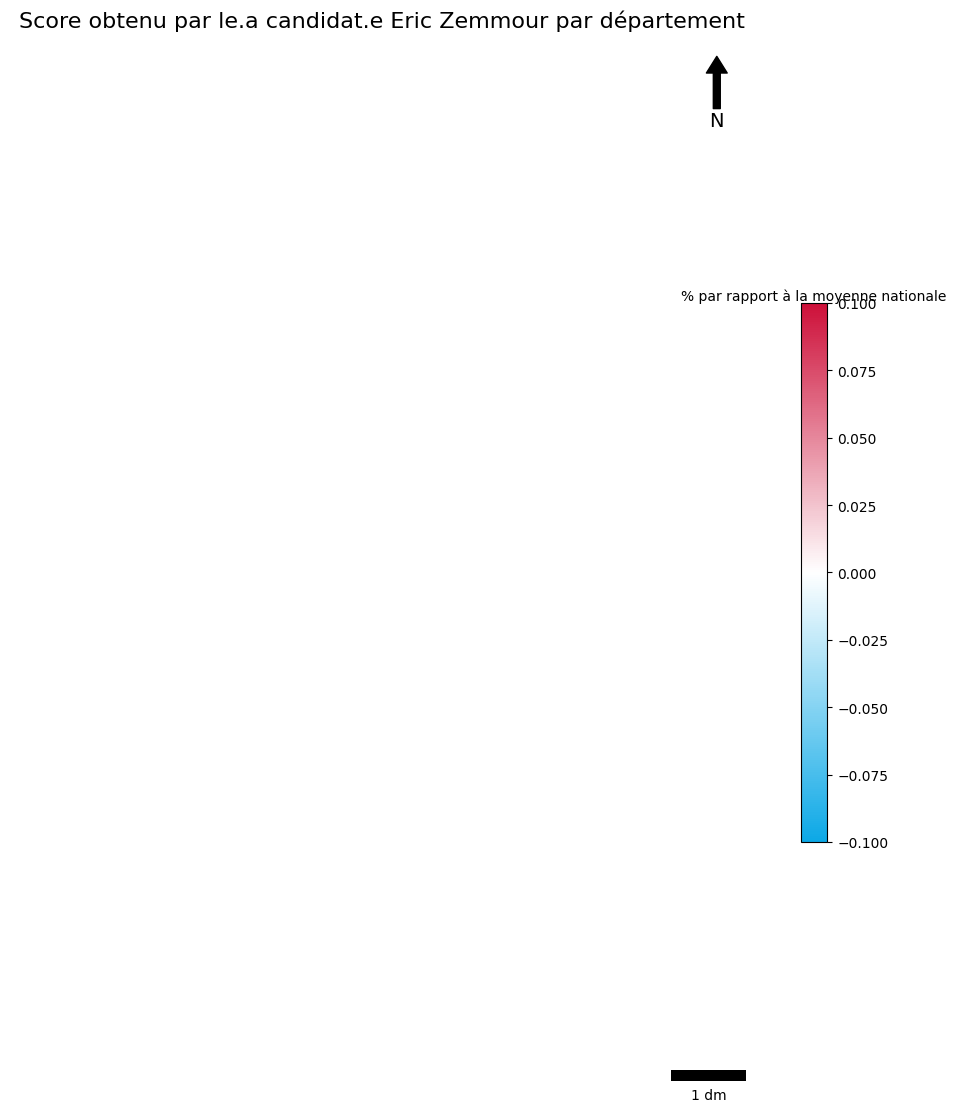

In [ ]:
cartographie.afficher_resultats_filtre_score_candidat(df_score=score_departements, candidat="Eric Zemmour", afficher_carte=True)